<a href="https://colab.research.google.com/github/aurabinda90-dev/CFD-in-Python/blob/main/Step_5_Burgers%E2%80%99_Equation_in_1D.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Step 5: Burgers’ Equation in 1-D

In [ ]:
import numpy as np
import sympy as sp

In [ ]:
sp.init_printing(use_latex=True)

In [ ]:
x, nu, t = sp.symbols('x nu t')
phi = (sp.exp(-(x - 4 * t)**2 / (4 * nu * (t + 1))) +
       sp.exp(-(x - 4 * t - 2 * sp.pi)**2 / (4 * nu * (t + 1))))
phi

                  2                2 
 -(-4⋅t + x - 2⋅π)      -(-4⋅t + x)  
 ───────────────────    ─────────────
     4⋅ν⋅(t + 1)         4⋅ν⋅(t + 1) 
ℯ                    + ℯ             

In [ ]:
phiprime = phi.diff(x)
phiprime

                           2                                         2 
                -(-4⋅t + x)                         -(-4⋅t + x - 2⋅π)  
                ─────────────                       ───────────────────
                 4⋅ν⋅(t + 1)                            4⋅ν⋅(t + 1)    
  (-8⋅t + 2⋅x)⋅ℯ                (-8⋅t + 2⋅x - 4⋅π)⋅ℯ                   
- ─────────────────────────── - ───────────────────────────────────────
          4⋅ν⋅(t + 1)                         4⋅ν⋅(t + 1)              

In [ ]:
print(phiprime)

-(-8*t + 2*x)*exp(-(-4*t + x)**2/(4*nu*(t + 1)))/(4*nu*(t + 1)) - (-8*t + 2*x - 4*pi)*exp(-(-4*t + x - 2*pi)**2/(4*nu*(t + 1)))/(4*nu*(t + 1))


In [ ]:
from sympy.utilities.lambdify import lambdify

u = -2 * nu * (phiprime / phi) + 4
u

      ⎛                           2                                         2  ↪
      ⎜                -(-4⋅t + x)                         -(-4⋅t + x - 2⋅π)   ↪
      ⎜                ─────────────                       ─────────────────── ↪
      ⎜                 4⋅ν⋅(t + 1)                            4⋅ν⋅(t + 1)     ↪
      ⎜  (-8⋅t + 2⋅x)⋅ℯ                (-8⋅t + 2⋅x - 4⋅π)⋅ℯ                    ↪
  2⋅ν⋅⎜- ─────────────────────────── - ─────────────────────────────────────── ↪
      ⎝          4⋅ν⋅(t + 1)                         4⋅ν⋅(t + 1)               ↪
- ──────────────────────────────────────────────────────────────────────────── ↪
                                        2                2                     ↪
                       -(-4⋅t + x - 2⋅π)      -(-4⋅t + x)                      ↪
                       ───────────────────    ─────────────                    ↪
                           4⋅ν⋅(t + 1)         4⋅ν⋅(t + 1)                     ↪
                      ℯ     

In [ ]:
ufunc = lambdify((t,x,nu),u)
ufunc(1,4,3)

np.float64(3.49170664206445)

In [ ]:
from matplotlib import pyplot as plt

## variable declarations
nx = 401
nt = 100
dx = 2 * np.pi / (nx - 1)

nu = 0.07
dt = dx * nu

x = np.linspace(0,2*np.pi,nx)
un = np.zeros(nx)

t = 0

u = np.asarray([ufunc(t, x0, nu) for x0 in x])
# Convert ufunc to a numpy array u using np.asarray
# t = 0, nu = 0.07 and x0 in x, which is a np.linspace
#print(u)
u[-1]

np.float64(4.0)

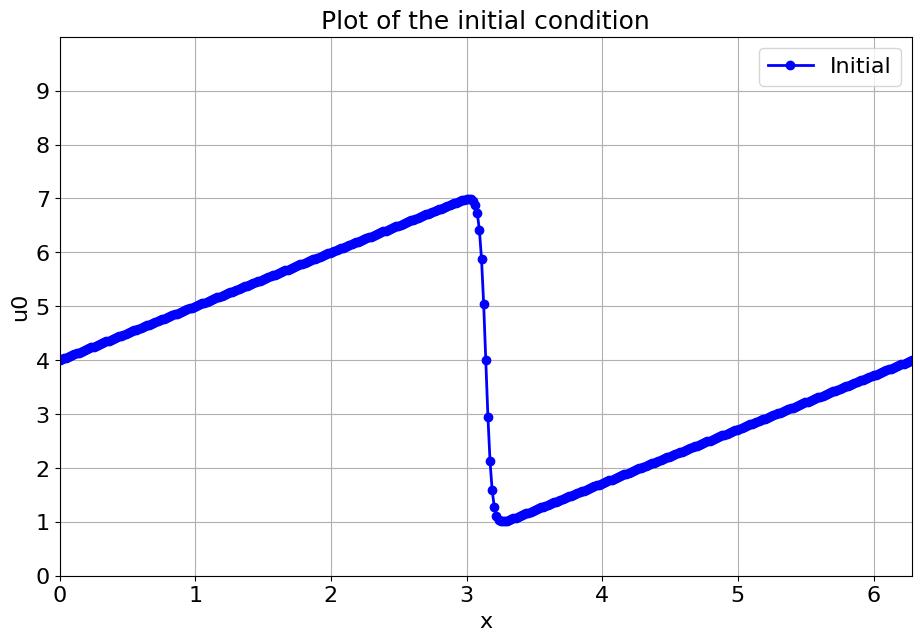

In [ ]:
# Set default font to Arial
plt.rcParams['font.family'] = 'arial'
# Set default font size
plt.rcParams['font.size'] = 16

# Create a new figure with a specific size
plt.figure(figsize=(11, 7), dpi = 100)

# Use pyplot to create a line plot of y vs. x with a specific color, linewidth, and label for the legend
plt.plot(x, u, color='blue', linewidth=2, marker='o', label='Initial')

# Add labels to the x and y axes with a specific font size
plt.xlabel('x', fontsize=16)
plt.ylabel('u0', fontsize=16)

# Add a title with a specific font size
plt.title('Plot of the initial condition', fontsize=18)

# Add a grid
plt.grid(True)

# Add a legend with a specific location
plt.legend(loc='upper right')

# Set the limit for the x and y axes
plt.xlim([0, 2*np.pi])
plt.ylim([0, 10])

# Set the ticks for the x and y axes
plt.xticks(np.arange(0, 2*np.pi, 1))
plt.yticks(np.arange(0, 10, 1))

# Display the plot
plt.show()

In [ ]:
for n in range(nt):
    un = u.copy()
    for i in range(1, nx-1):
        u[i] = un[i] - un[i] * dt / dx *(un[i] - un[i-1]) + nu * dt / dx**2 *\
                (un[i+1] - 2 * un[i] + un[i-1])
    u[-1] = un[-1] - un[-1] * dt / dx *(un[-1] - un[-2]) + nu * dt / dx**2 *\
                (un[1] - 2 * un[-1] + un[-2])
    u[0] = u[-1]


u_analy = np.asarray([ufunc(nt * dt, xi, nu) for xi in x])

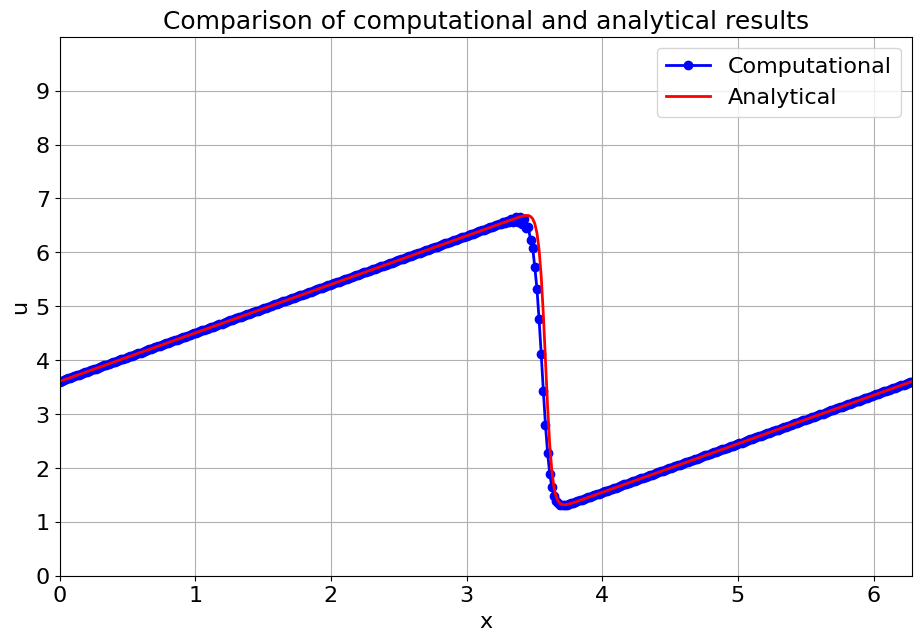

In [ ]:
# Create a new figure with a specific size
plt.figure(figsize=(11, 7), dpi = 100)
plt.plot(x, u, color='blue', linewidth=2, marker='o', label='Computational')
plt.plot(x, u_analy, color='red', linewidth=2, label='Analytical')
# Add labels to the x and y axes with a specific font size
plt.xlabel('x', fontsize=16)
plt.ylabel('u', fontsize=16)

# Add a title with a specific font size
plt.title('Comparison of computational and analytical results', fontsize=18)

# Add a grid
plt.grid(True)

# Add a legend with a specific location
plt.legend(loc='upper right')

# Set the limit for the x and y axes
plt.xlim([0, 2*np.pi])
plt.ylim([0, 10])

# Set the ticks for the x and y axes
plt.xticks(np.arange(0, 2*np.pi, 1))
plt.yticks(np.arange(0, 10, 1))

# Display the plot
plt.show()